In [1]:
import os
import pickle
from typing import List

import torch
import torch.nn.functional as F
from torchvision import transforms

import numpy as np
import matplotlib.pyplot as plt

from models import transformers
from utils import ViTSplit, StatsCalc

from datasets import load_from_disk, concatenate_datasets

### Dataset Loading

In [2]:
DATASET_PATH = os.getenv("datasetPath")
IMG_FOLDER_PATH = os.getenv("imgFolderPath")
ARTIFACTS_PATH = os.getenv("artifactsPath")

In [3]:
main_dataset = load_from_disk(DATASET_PATH)

In [4]:
train_set = concatenate_datasets([main_dataset["train"], main_dataset["test"]])
val_set = main_dataset["valid"]
print(f"Training length: {len(train_set)}")
print(f"Validation length: {len(val_set)}")

Training length: 9397
Validation length: 976


### Splitting visualization

Picture mode: L
Picture shape: torch.Size([1, 128, 2467])


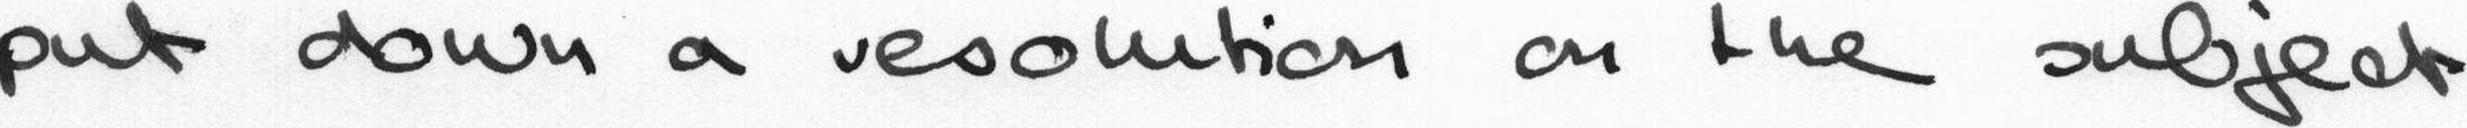

In [5]:
picture_sample = train_set[0]["image"]
print(f"Picture mode: {picture_sample.mode}")
print(f"Picture shape: {transforms.ToTensor()(picture_sample).shape}")
picture_sample

In [6]:
transformations = transforms.Compose([transforms.ToTensor(), transforms.Resize((128, 256))])

Picture after resizing
Picture shape: torch.Size([1, 128, 256])


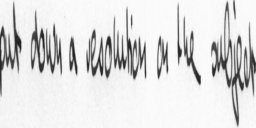

In [7]:
print('Picture after resizing')
resized_picture = transformations(picture_sample)
print(f'Picture shape: {resized_picture.shape}')
transforms.functional.to_pil_image(transformations(picture_sample))

In [8]:
split = ViTSplit(pic_size=(1, 128, 256), split_size=4)

In [9]:
splitted_values = split(resized_picture)
print(f"Number of splitted values should be {256//4}")
print(f"In reality: {len(splitted_values)}")
print(f"If concatenated back values match: {bool((torch.cat(splitted_values, dim=-1) == resized_picture).all())}")

Number of splitted values should be 64
In reality: 64
If concatenated back values match: True


In [10]:
def visualize_horizontal_strips(
    strips: List[torch.Tensor],
    figsize: tuple = (15, 4)
) -> plt.Figure:
    """
    Visualize horizontal image strips in a single row.
    
    Args:
        strips: List of tensors, each of shape (C, H, W) where C=1 or 3
        figsize: Figure size for the complete visualization
    
    Returns:
        matplotlib.figure.Figure: The created figure
    """
    n_strips = len(strips)
    fig, axes = plt.subplots(1, n_strips, figsize=figsize)
    fig.set_facecolor("black")
    
    if n_strips == 1:
        axes = [axes]
    
    for i, (strip, ax) in enumerate(zip(strips, axes)):
        img = strip.squeeze().cpu().numpy()
        ax.imshow(img, cmap = 'gray')
        ax.axis('off')
    
    plt.tight_layout()
    return fig

In [11]:
# Calculate statistcs and add normalization transformation to picture
stat_calc = StatsCalc(dataset=train_set,
                      img_transforms=transforms.Compose([transforms.ToTensor(), transforms.Resize((128, 256))]),
                      img_size=(128, 256))

In [12]:
# stat_calc.compute_statistics()
# stat_calc.save(ARTIFACTS_PATH + r"\statistics_dict.pkl")

In [13]:
with open(ARTIFACTS_PATH + r"\statistics_dict.pkl", r"rb") as stat_dict_file:
    statistics = pickle.load(stat_dict_file)

statistics

{'mean': 0.9136844277381897, 'std': 0.14744582772254944}

In [31]:
transformations_with_norm = transforms.Compose([transforms.ToTensor(),
                                                transforms.Resize((384, 384)),
                                                transforms.Normalize(mean=(statistics["mean"], ), std=(statistics["std"], ))])

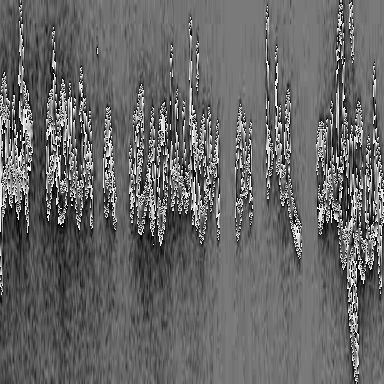

In [32]:
resized_and_normalized = transformations_with_norm(picture_sample)
resized_and_normalized_pil = transforms.functional.to_pil_image(resized_and_normalized)
resized_and_normalized_pil

In [16]:
resized_and_normalized_pil.save(fp=IMG_FOLDER_PATH+r"\\resized_and_normalized.png")

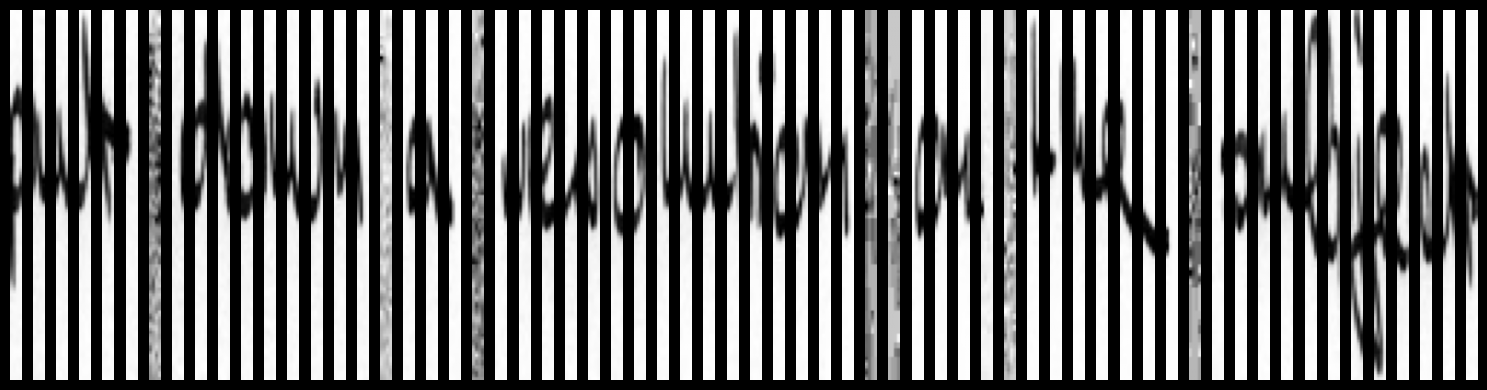

In [17]:
fig = visualize_horizontal_strips(strips=split(resized_and_normalized))

In [19]:
# fig.savefig(IMG_FOLDER_PATH+r"\\splitted_picture.png")

In [24]:
import requests
from PIL import Image

In [25]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

In [30]:
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
processor

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

c:\main\GitHub\myNumpy\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\luchi\.cache\huggingface\hub\models--microsoft--trocr-base-handwritten. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fa

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

TrOCRProcessor:
- image_processor: ViTImageProcessor {
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 384,
    "width": 384
  }
}

- tokenizer: RobertaTokenizerFast(name_or_path='microsoft/trocr-base-handwritten', vocab_size=50265, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=Tr

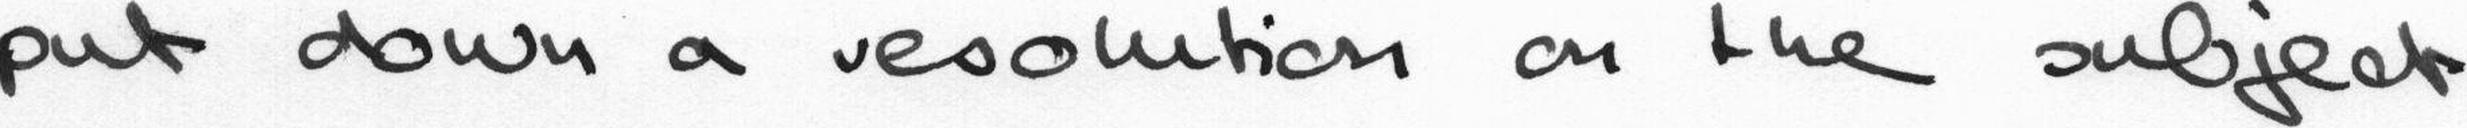

In [35]:
picture_sample.convert("RGB")

In [39]:
result = processor(picture_sample.convert("RGB"), return_tensors="pt").pixel_values
result

tensor([[[[0.9529, 0.9529, 0.9451,  ..., 0.9608, 0.9686, 0.9686],
          [0.9529, 0.9529, 0.9451,  ..., 0.9608, 0.9686, 0.9686],
          [0.9529, 0.9529, 0.9451,  ..., 0.9608, 0.9686, 0.9686],
          ...,
          [0.9216, 0.9059, 0.9059,  ..., 0.9686, 0.9686, 0.9608],
          [0.9216, 0.9059, 0.9059,  ..., 0.9686, 0.9686, 0.9608],
          [0.9216, 0.9059, 0.9059,  ..., 0.9686, 0.9686, 0.9608]],

         [[0.9529, 0.9529, 0.9451,  ..., 0.9608, 0.9686, 0.9686],
          [0.9529, 0.9529, 0.9451,  ..., 0.9608, 0.9686, 0.9686],
          [0.9529, 0.9529, 0.9451,  ..., 0.9608, 0.9686, 0.9686],
          ...,
          [0.9216, 0.9059, 0.9059,  ..., 0.9686, 0.9686, 0.9608],
          [0.9216, 0.9059, 0.9059,  ..., 0.9686, 0.9686, 0.9608],
          [0.9216, 0.9059, 0.9059,  ..., 0.9686, 0.9686, 0.9608]],

         [[0.9529, 0.9529, 0.9451,  ..., 0.9608, 0.9686, 0.9686],
          [0.9529, 0.9529, 0.9451,  ..., 0.9608, 0.9686, 0.9686],
          [0.9529, 0.9529, 0.9451,  ..., 0

In [40]:
result.shape

torch.Size([1, 3, 384, 384])

In [41]:
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [42]:
model

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (i

In [44]:
model.to(device='cuda')

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (i

In [72]:
model.encoder.embeddings.dropout.p = 0.25

In [107]:
for layer in model.encoder.encoder.layer:
    layer.attention.output.dropout.p = 0.25
    layer.output.dropout.p = 0.25

In [148]:
model.decoder.resize_token_embeddings(41)
model.decoder.model.decoder.embed_tokens.padding_idx = 0

In [45]:
!nvidia-smi

Sun Feb  8 21:22:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.74                 Driver Version: 591.74         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   48C    P0             19W /   50W |    1391MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [46]:
from torchvision.transforms import ToTensor

In [47]:
pil_to_tensor = ToTensor()

In [50]:
tensor_picture = pil_to_tensor(picture_sample)
tensor_picture

tensor([[[0.9843, 0.9804, 0.9765,  ..., 0.9804, 0.9804, 0.9804],
         [0.9804, 0.9765, 0.9765,  ..., 0.9804, 0.9804, 0.9804],
         [0.9804, 0.9765, 0.9725,  ..., 0.9804, 0.9804, 0.9804],
         ...,
         [0.9529, 0.9529, 0.9569,  ..., 0.9843, 0.9843, 0.9843],
         [0.9608, 0.9569, 0.9608,  ..., 0.9804, 0.9804, 0.9804],
         [0.9647, 0.9608, 0.9608,  ..., 0.9765, 0.9765, 0.9765]]])

In [51]:
tensor_picture.shape

torch.Size([1, 128, 2467])

In [205]:
processed_picture = processor(picture_sample.convert("RGB"), return_tensors="pt").pixel_values
processed_picture.shape

torch.Size([1, 3, 384, 384])

In [206]:
processed_picture.to(device="cuda").shape

torch.Size([1, 3, 384, 384])

In [207]:
result = model.encoder(processed_picture.to(device='cuda'))

In [208]:
result["last_hidden_state"].shape

torch.Size([1, 577, 768])

In [214]:
decoder_tensor = model.decoder(torch.tensor([[1, 2, 3, 4, 0]], dtype=torch.long).to(device='cuda'), encoder_hidden_states = result["last_hidden_state"]).logits
decoder_tensor

tensor([[[-3.0645, -0.3737,  0.8758, -2.9843,  8.5421,  4.4567,  8.6281,
           1.0822,  1.0500, -0.2512, -0.2883, -1.1384,  7.7486,  1.6898,
           6.8080, -0.4575, -3.1211,  6.1100,  0.9781,  5.2764,  0.4671,
          -2.9472,  7.8253,  0.7431,  1.5611, -3.6269,  4.3190,  0.6510,
           0.2705, 11.5447, -0.0522,  0.7596,  1.8247,  1.6280, -0.0236,
           7.6542,  6.2767,  2.9386, -0.2136, -0.3217,  6.1182],
         [-3.0595, -0.2174,  1.3782, -1.6777, 10.2319,  2.1497,  5.5555,
           0.6259, -1.8671,  2.0341,  0.2551, -0.2348,  6.5738, -2.7536,
           5.3150, -4.3903,  0.1252,  2.3108,  2.3844,  2.3990,  0.4115,
          -0.2624,  8.1600,  3.5558,  5.3505, -4.9175, -0.7302,  0.1422,
          -1.4126,  2.4142, -3.3741, -3.0169,  0.8938,  2.5375,  1.6373,
           6.3598,  4.8145,  1.3636,  2.0729,  2.0848,  3.2302],
         [-3.4889, -3.2681,  8.2210, -6.7980,  6.2323,  9.2992,  5.7214,
          12.6162, 10.5259,  9.1931, 19.0599, 15.1390,  6.1144,  7.

In [ ]:
decoder_tensor.shape

torch.Size([1, 5, 41])

In [163]:
logit_values = model(processed_picture.to(device="cuda"), decoder_input_ids = torch.tensor([[1, 2, 3, 4, 0]], dtype=torch.long).to(device='cuda')).logits
logit_values

tensor([[[-3.0645, -0.3737,  0.8758, -2.9843,  8.5421,  4.4567,  8.6281,
           1.0822,  1.0500, -0.2512, -0.2883, -1.1384,  7.7486,  1.6898,
           6.8080, -0.4575, -3.1211,  6.1100,  0.9781,  5.2764,  0.4671,
          -2.9472,  7.8253,  0.7431,  1.5611, -3.6269,  4.3190,  0.6510,
           0.2705, 11.5447, -0.0522,  0.7596,  1.8247,  1.6280, -0.0236,
           7.6542,  6.2767,  2.9386, -0.2136, -0.3217,  6.1182],
         [-3.0595, -0.2174,  1.3782, -1.6777, 10.2319,  2.1497,  5.5555,
           0.6259, -1.8671,  2.0341,  0.2551, -0.2348,  6.5738, -2.7536,
           5.3150, -4.3903,  0.1252,  2.3108,  2.3844,  2.3990,  0.4115,
          -0.2624,  8.1600,  3.5558,  5.3505, -4.9175, -0.7302,  0.1422,
          -1.4126,  2.4142, -3.3741, -3.0169,  0.8938,  2.5375,  1.6373,
           6.3598,  4.8145,  1.3636,  2.0729,  2.0848,  3.2302],
         [-3.4889, -3.2681,  8.2210, -6.7980,  6.2323,  9.2992,  5.7214,
          12.6162, 10.5259,  9.1931, 19.0599, 15.1390,  6.1144,  7.

In [165]:
logit_values.shape

torch.Size([1, 5, 41])

In [58]:
conv = nn.Conv2d(3, 768, kernel_size=(16, 16))
conv

Conv2d(3, 768, kernel_size=(16, 16), stride=(1, 1))

In [60]:
conv(processed_picture).shape

torch.Size([1, 768, 369, 369])

In [210]:
import sys
sys.path.append("modelInference")

from inference_utils import ModelInference

In [212]:
model_inf = ModelInference(
    model = trocr_model,
    transformations = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten"),
    tokenizer = tokenizer,
    split = None
)

NameError: name 'trocr_model' is not defined